# Main Association Model Sensitivity

Fit the main SSE association analysis under several regression and adjustment choices, then compare convergence, warnings, Wald tests, and odds ratios.

The notebook writes each scenario to its own directory under `sse_detection/results/main_model_sensitivity/`, so it does not overwrite the standard `association_outputs` tables.

## Setup

In [5]:
from __future__ import annotations

from pathlib import Path
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "sse_detection":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from sse_detection import lib as sselib  # noqa: E402

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)

SSE_OUTPUT_DIR = PROJECT_ROOT / "sse_detection" / "results" / "sse_outputs"
RESULTS_ROOT = PROJECT_ROOT / "sse_detection" / "results" / "main_model_sensitivity"
COMBINED_DIR = RESULTS_ROOT / "combined"
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
COMBINED_DIR.mkdir(parents=True, exist_ok=True)

MIXING_REFERENCE = "per 1 null-model SD increase in entropy"
WINDOW_STRIDE = 2

SSE_OUTPUT_DIR, RESULTS_ROOT

(PosixPath('/Users/ydnkka/Desktop/PhD Project/projects/scotland/sse_detection/results/sse_outputs'),
 PosixPath('/Users/ydnkka/Desktop/PhD Project/projects/scotland/sse_detection/results/main_model_sensitivity'))

## Scenario Grid

`firth_glm` is the current primary estimator. `glm_clustered` is included as a faster robustness check with cluster-robust standard errors. The grid intentionally contains only these two GLM-based fitting methods.

In [6]:
RUN_FITS = False  # Set to True to run the models; otherwise, just load the results from disk.
SCENARIOS_TO_RUN = None  # None runs every scenario with run=True; otherwise use a list of scenario names.

SCENARIOS = [
    {
        "scenario": "firth_full",
        "label": "Firth: window + clade",
        "model_method": "firth_glm",
        "variant_adjuster": "clade",
        "window_adjustment": "fixed_effects",
        "run": True,
    },
    {
        "scenario": "firth_time_only",
        "label": "Firth: window only",
        "model_method": "firth_glm",
        "variant_adjuster": None,
        "window_adjustment": "fixed_effects",
        "run": True,
    },
    {
        "scenario": "firth_clade_only",
        "label": "Firth: clade only",
        "model_method": "firth_glm",
        "variant_adjuster": "clade",
        "window_adjustment": "none",
        "run": True,
    },
    {
        "scenario": "firth_clade_surveillance",
        "label": "Firth: clade + surveillance",
        "model_method": "firth_glm",
        "variant_adjuster": "clade",
        "window_adjustment": "surveillance",
        "run": True,
    },
    {
        "scenario": "glm_full",
        "label": "Clustered GLM: window + clade",
        "model_method": "glm_clustered",
        "variant_adjuster": "clade",
        "window_adjustment": "fixed_effects",
        "run": True,
    },
    {
        "scenario": "glm_time_only",
        "label": "Clustered GLM: window only",
        "model_method": "glm_clustered",
        "variant_adjuster": None,
        "window_adjustment": "fixed_effects",
        "run": True,
    },
    {
        "scenario": "glm_clade_only",
        "label": "Clustered GLM: clade only",
        "model_method": "glm_clustered",
        "variant_adjuster": "clade",
        "window_adjustment": "none",
        "run": True,
    },
    {
        "scenario": "glm_clade_surveillance",
        "label": "Clustered GLM: clade + surveillance",
        "model_method": "glm_clustered",
        "variant_adjuster": "clade",
        "window_adjustment": "surveillance",
        "run": True,
    },
]

scenario_table = pd.DataFrame(SCENARIOS)
scenario_table["result_dir"] = scenario_table["scenario"].map(
    lambda name: str(RESULTS_ROOT / name)
)
scenario_table

,scenario,label,model_method,variant_adjuster,window_adjustment,run,result_dir
0,firth_full,Firth: window + clade,firth_glm,clade,fixed_effects,True,/Users/ydnkka/Desktop/PhD Project/projects/scotland/sse_detection/results/main_model_sensitivity/firth_full
1,firth_time_only,Firth: window only,firth_glm,NaN,fixed_effects,True,/Users/ydnkka/Desktop/PhD Project/projects/scotland/sse_detection/results/main_model_sensitivity/firth_time_only
2,firth_clade_only,Firth: clade only,firth_glm,clade,none,True,/Users/ydnkka/Desktop/PhD Project/projects/scotland/sse_detection/results/main_model_sensitivity/firth_clade_only
3,firth_clade_surveillance,Firth: clade + surveillance,firth_glm,clade,surveillance,True,/Users/ydnkka/Desktop/PhD Project/projects/scotland/sse_detection/results/main_model_sensitivity/firth_clade_surveillance
4,glm_full,Clustered GLM: window + clade,glm_clustered,clade,fixed_effects,True,/Users/ydnkka/Desktop/PhD Project/projects/scotland/sse_detection/results/main_model_sensitivity/glm_full
5,glm_time_only,Clustered GLM: window only,glm_clustered,NaN,fixed_effects,True,/Users/ydnkka/Desktop/PhD Project/projects/scotland/sse_detection/results/main_model_sensitivity/glm_time_only
6,glm_clade_only,Clustered GLM: clade only,glm_clustered,clade,none,True,/Users/ydnkka/Desktop/PhD Project/projects/scotland/sse_detection/results/main_model_sensitivity/glm_clade_only
7,glm_clade_surveillance,Clustered GLM: clade + surveillance,glm_clustered,clade,surveillance,True,/Users/ydnkka/Desktop/PhD Project/projects/scotland/sse_detection/results/main_model_sensitivity/glm_clade_surveillance


## Fit Models

Set `RUN_FITS = False` above to skip fitting and only read previously generated scenario tables.

In [7]:
def selected_scenarios() -> list[dict]:
    selected = []
    requested = set(SCENARIOS_TO_RUN or [])
    for spec in SCENARIOS:
        if requested:
            if spec["scenario"] in requested:
                selected.append(spec)
        elif spec.get("run", True):
            selected.append(spec)
    return selected


def run_scenario(spec: dict) -> dict:
    result_dir = RESULTS_ROOT / spec["scenario"]
    result_dir.mkdir(parents=True, exist_ok=True)
    started = time.perf_counter()
    result = sselib.run_main_association_analysis(
        output_dir=SSE_OUTPUT_DIR,
        result_dir=result_dir,
        model_method=spec["model_method"],
        variant_adjuster=spec["variant_adjuster"],
        window_adjustment=spec["window_adjustment"],
        mixing_reference=MIXING_REFERENCE,
        window_stride=WINDOW_STRIDE,
    )
    elapsed = time.perf_counter() - started
    failures = result.get("failures", pd.DataFrame())
    return {
        "scenario": spec["scenario"],
        "elapsed_seconds": elapsed,
        "result_dir": str(result_dir),
        "n_model_failures": 0 if failures is None else len(failures),
    }


run_log = []
if RUN_FITS:
    for spec in selected_scenarios():
        print(f"Running {spec['scenario']}: {spec['label']}")
        run_log.append(run_scenario(spec))
        print(f"  finished in {run_log[-1]['elapsed_seconds']:.1f}s")
else:
    print("RUN_FITS=False; reading existing scenario CSVs only.")

run_log = pd.DataFrame(run_log)
if not run_log.empty:
    run_log.to_csv(COMBINED_DIR / "run_log.csv", index=False)
run_log

RUN_FITS=False; reading existing scenario CSVs only.


""


## Load Scenario Tables

In [8]:
TABLE_FILES = {
    "composition_wald": "composition_wald.csv",
    "composition_odds_ratios": "composition_odds_ratios.csv",
    "composition_fit_stats": "composition_fit_stats.csv",
    "mixing_wald": "mixing_wald.csv",
    "mixing_odds_ratios": "mixing_odds_ratios.csv",
    "mixing_fit_stats": "mixing_fit_stats.csv",
    "cluster_diagnostics": "cluster_diagnostics.csv",
    "model_failures": "model_failures.csv",
}

SCENARIO_META = pd.DataFrame(SCENARIOS).drop(columns=["run"])
SCENARIO_META["variant_adjuster"] = SCENARIO_META["variant_adjuster"].fillna("none")
SCENARIO_META["adjustment"] = (
    "window="
    + SCENARIO_META["window_adjustment"].astype(str)
    + "; variant="
    + SCENARIO_META["variant_adjuster"].astype(str)
)


def add_scenario_metadata(df: pd.DataFrame, spec: dict) -> pd.DataFrame:
    out = df.copy()
    out.insert(0, "scenario", spec["scenario"])
    out.insert(1, "scenario_label", spec["label"])
    out.insert(2, "model_method", spec["model_method"])
    out.insert(
        3,
        "adjustment",
        f"window={spec['window_adjustment']}; variant={spec['variant_adjuster'] or 'none'}",
    )
    return out


def load_tables() -> tuple[dict[str, pd.DataFrame], pd.DataFrame]:
    loaded: dict[str, list[pd.DataFrame]] = {key: [] for key in TABLE_FILES}
    skipped = []
    for spec in selected_scenarios():
        result_dir = RESULTS_ROOT / spec["scenario"]
        for key, filename in TABLE_FILES.items():
            path = result_dir / filename
            row = {"scenario": spec["scenario"], "table": key, "path": str(path)}
            if not path.exists():
                skipped.append({**row, "reason": "missing"})
                continue
            if not path.read_text(errors="replace").strip():
                skipped.append({**row, "reason": "blank"})
                continue
            try:
                table = pd.read_csv(path, skipinitialspace=True)
            except pd.errors.EmptyDataError:
                skipped.append({**row, "reason": "empty_csv"})
                continue
            loaded[key].append(add_scenario_metadata(table, spec))
    combined = {
        key: pd.concat(tables, ignore_index=True) if tables else pd.DataFrame()
        for key, tables in loaded.items()
    }
    return combined, pd.DataFrame(skipped)


tables, missing_tables = load_tables()
for key, table in tables.items():
    if not table.empty:
        table.to_csv(COMBINED_DIR / f"{key}.csv", index=False)

{key: len(table) for key, table in tables.items()}, missing_tables.head(10)

({'composition_wald': 160,
  'composition_odds_ratios': 1216,
  'composition_fit_stats': 96,
  'mixing_wald': 144,
  'mixing_odds_ratios': 256,
  'mixing_fit_stats': 144,
  'cluster_diagnostics': 16,
  'model_failures': 0},
                    scenario           table  \
 0                firth_full  model_failures   
 1           firth_time_only  model_failures   
 2          firth_clade_only  model_failures   
 3  firth_clade_surveillance  model_failures   
 4                  glm_full  model_failures   
 5             glm_time_only  model_failures   
 6            glm_clade_only  model_failures   
 7    glm_clade_surveillance  model_failures   
 
                                                                                                                                            path  \
 0                /Users/ydnkka/Desktop/PhD Project/projects/scotland/sse_detection/results/main_model_sensitivity/firth_full/model_failures.csv   
 1           /Users/ydnkka/Desktop/PhD Project

## Convergence And Warning Summary

In [9]:
def false_like(series: pd.Series) -> pd.Series:
    return series.astype(str).str.strip().str.lower().eq("false")


def positive_like(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce").fillna(0).gt(0)


fit_stats = pd.concat(
    [
        tables["composition_fit_stats"],
        tables["mixing_fit_stats"],
    ],
    ignore_index=True,
)

if fit_stats.empty:
    raise ValueError(
        "No fit-stat tables are loaded. Run the scenario fit cell or check RESULTS_ROOT."
    )

fit_stats["nonconverged"] = (
    false_like(fit_stats["converged"]) if "converged" in fit_stats else False
)
fit_stats["warned"] = (
    positive_like(fit_stats["fit_warning_count"])
    if "fit_warning_count" in fit_stats
    else False
)

fit_summary = (
    fit_stats.groupby(
        ["scenario", "scenario_label", "model_method", "adjustment", "domain"],
        dropna=False,
    )
    .agg(
        n_fits=("model", "size"),
        nonconverged=("nonconverged", "sum"),
        warned=("warned", "sum"),
        max_iterations=("iterations", "max")
        if "iterations" in fit_stats
        else ("model", "size"),
    )
    .reset_index()
    .sort_values(["model_method", "scenario", "domain"])
)
fit_summary.to_csv(COMBINED_DIR / "fit_summary.csv", index=False)
fit_summary

,scenario,scenario_label,model_method,adjustment,domain,n_fits,nonconverged,warned,max_iterations
0,firth_clade_only,Firth: clade only,firth_glm,window=none; variant=clade,composition,12,5,5,29.0
1,firth_clade_only,Firth: clade only,firth_glm,window=none; variant=clade,node_mixing,18,7,7,31.0
2,firth_clade_surveillance,Firth: clade + surveillance,firth_glm,window=surveillance; variant=clade,composition,12,9,9,45.0
3,firth_clade_surveillance,Firth: clade + surveillance,firth_glm,window=surveillance; variant=clade,node_mixing,18,7,7,100.0
4,firth_full,Firth: window + clade,firth_glm,window=fixed_effects; variant=clade,composition,12,3,3,44.0
5,firth_full,Firth: window + clade,firth_glm,window=fixed_effects; variant=clade,node_mixing,18,7,7,33.0
6,firth_time_only,Firth: window only,firth_glm,window=fixed_effects; variant=none,composition,12,0,0,8.0
7,firth_time_only,Firth: window only,firth_glm,window=fixed_effects; variant=none,node_mixing,18,6,6,100.0
8,glm_clade_only,Clustered GLM: clade only,glm_clustered,window=none; variant=clade,composition,12,0,0,NaN
9,glm_clade_only,Clustered GLM: clade only,glm_clustered,window=none; variant=clade,node_mixing,18,0,0,NaN


Rows with convergence warnings or non-convergence:

In [10]:
fit_issues = fit_stats.loc[
    fit_stats["nonconverged"] | fit_stats["warned"],
    [
        "scenario",
        "scenario_label",
        "domain",
        "model_set",
        "predictor_set",
        "predictor",
        "model",
        "converged",
        "iterations",
        "fit_warning_count",
        "fit_warnings",
        "formula",
    ],
].sort_values(["scenario", "domain", "model_set", "predictor_set", "predictor"])
fit_issues.to_csv(COMBINED_DIR / "fit_issues.csv", index=False)
fit_issues

,scenario,scenario_label,domain,model_set,predictor_set,predictor,model,converged,iterations,fit_warning_count,fit_warnings,formula
30,firth_clade_only,Firth: clade only,composition,expanded,single,sex,composition__expanded__single__sex,False,25.0,1,ConvergenceWarning: Step-halving failed to converge.,"candidate ~ C(sex, Treatment(reference='Male')) + C(clade) + z_dz_cum_prop_sequenced + z_dz_cum_incidence_per_capita + z_dz_7d_test_positivity + z_log1p_dz_..."
29,firth_clade_only,Firth: clade only,composition,primary,joint,all_composition,composition__primary__joint,False,17.0,1,ConvergenceWarning: Step-halving failed to converge.,"candidate ~ C(sex, Treatment(reference='Male')) + C(age_band, Treatment(reference='20-24')) + C(dz_simd_quintile, Treatment(reference='1')) + C(dz_urban_rur..."
28,firth_clade_only,Firth: clade only,composition,primary,single,health_board,composition__primary__single__health_board,False,29.0,1,ConvergenceWarning: Step-halving failed to converge.,"candidate ~ C(dz_health_board, Treatment(reference='Greater Glasgow and Clyde')) + C(clade)"
26,firth_clade_only,Firth: clade only,composition,primary,single,simd_quintile,composition__primary__single__simd_quintile,False,22.0,1,ConvergenceWarning: Step-halving failed to converge.,"candidate ~ C(dz_simd_quintile, Treatment(reference='1')) + C(clade)"
27,firth_clade_only,Firth: clade only,composition,primary,single,urban_rural_class,composition__primary__single__urban_rural_class,False,18.0,1,ConvergenceWarning: Step-halving failed to converge.,"candidate ~ C(dz_urban_rural_class, Treatment(reference='Large Urban Areas')) + C(clade)"
149,firth_clade_only,Firth: clade only,node_mixing,expanded,joint,all_mixing,mixing__expanded__joint,False,11.0,1,ConvergenceWarning: Step-halving failed to converge.,candidate ~ sex_entropy_z + age_entropy_z + simd_entropy_z + datazone_entropy_z + local_authority_entropy_z + urban_rural_entropy_z + health_board_entropy_z...
142,firth_clade_only,Firth: clade only,node_mixing,expanded,single,age_entropy_z,mixing__expanded__single__age_entropy_z,False,19.0,1,ConvergenceWarning: Step-halving failed to converge.,candidate ~ age_entropy_z + C(clade) + z_dz_cum_prop_sequenced + z_dz_cum_incidence_per_capita + z_dz_7d_test_positivity + z_log1p_dz_cum_positive_tests
144,firth_clade_only,Firth: clade only,node_mixing,expanded,single,datazone_entropy_z,mixing__expanded__single__datazone_entropy_z,False,31.0,1,ConvergenceWarning: Step-halving failed to converge.,candidate ~ datazone_entropy_z + C(clade) + z_dz_cum_prop_sequenced + z_dz_cum_incidence_per_capita + z_dz_7d_test_positivity + z_log1p_dz_cum_positive_tests
143,firth_clade_only,Firth: clade only,node_mixing,expanded,single,simd_entropy_z,mixing__expanded__single__simd_entropy_z,False,13.0,1,ConvergenceWarning: Step-halving failed to converge.,candidate ~ simd_entropy_z + C(clade) + z_dz_cum_prop_sequenced + z_dz_cum_incidence_per_capita + z_dz_7d_test_positivity + z_log1p_dz_cum_positive_tests
140,firth_clade_only,Firth: clade only,node_mixing,primary,joint,all_mixing,mixing__primary__joint,False,14.0,1,ConvergenceWarning: Step-halving failed to converge.,candidate ~ sex_entropy_z + age_entropy_z + simd_entropy_z + datazone_entropy_z + local_authority_entropy_z + urban_rural_entropy_z + health_board_entropy_z...


## Wald Test Comparison

In [11]:
wald = pd.concat(
    [tables["composition_wald"], tables["mixing_wald"]],
    ignore_index=True,
)
wald_primary = wald.loc[wald["model_set"].eq("primary")].copy()
wald_primary["minus_log10_p"] = -np.log10(
    pd.to_numeric(wald_primary["P>chi2"], errors="coerce")
)
wald_primary["minus_log10_p_adj"] = -np.log10(
    pd.to_numeric(wald_primary["p_adj_bh"], errors="coerce")
)

wald_view = wald_primary[
    [
        "scenario",
        "scenario_label",
        "model_method",
        "adjustment",
        "domain",
        "predictor_set",
        "predictor",
        "term",
        "chi2",
        "df",
        "P>chi2",
        "p_adj_bh",
        "minus_log10_p",
        "minus_log10_p_adj",
        "n_model_rows",
        "n_nodes",
    ]
].sort_values(["domain", "predictor_set", "predictor", "model_method", "scenario"])
wald_view.to_csv(COMBINED_DIR / "primary_wald_comparison.csv", index=False)
wald_view

/opt/homebrew/Caskroom/miniconda/base/envs/PhD/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/homebrew/Caskroom/miniconda/base/envs/PhD/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


,scenario,scenario_label,model_method,adjustment,domain,predictor_set,predictor,term,chi2,df,P>chi2,p_adj_bh,minus_log10_p,minus_log10_p_adj,n_model_rows,n_nodes
46,firth_clade_only,Firth: clade only,firth_glm,window=none; variant=clade,composition,joint,age_band,age_band,302.492189,15,1.695956e-55,8.479780e-55,54.770585,54.071615,264139,13059
66,firth_clade_surveillance,Firth: clade + surveillance,firth_glm,window=surveillance; variant=clade,composition,joint,age_band,age_band,260.866251,15,7.137100e-47,3.568550e-46,46.146478,45.447508,264139,13059
6,firth_full,Firth: window + clade,firth_glm,window=fixed_effects; variant=clade,composition,joint,age_band,age_band,26.943053,15,2.920377e-02,4.867295e-02,1.534561,1.312712,262747,12897
26,firth_time_only,Firth: window only,firth_glm,window=fixed_effects; variant=none,composition,joint,age_band,age_band,45.678059,15,5.981299e-05,1.302375e-04,4.223205,3.885264,262747,12897
126,glm_clade_only,Clustered GLM: clade only,glm_clustered,window=none; variant=clade,composition,joint,age_band,age_band,22.345507,15,9.905934e-02,1.650989e-01,1.004105,0.782256,264139,13059
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185,firth_time_only,Firth: window only,firth_glm,window=fixed_effects; variant=none,node_mixing,single,vaccination_entropy_z,vaccination_entropy_z,1.250879,1,2.633847e-01,3.511795e-01,0.579410,0.454471,12508,12508
275,glm_clade_only,Clustered GLM: clade only,glm_clustered,window=none; variant=clade,node_mixing,single,vaccination_entropy_z,vaccination_entropy_z,0.841042,1,3.590989e-01,4.787985e-01,0.444786,0.319847,12645,12645
293,glm_clade_surveillance,Clustered GLM: clade + surveillance,glm_clustered,window=surveillance; variant=clade,node_mixing,single,vaccination_entropy_z,vaccination_entropy_z,0.833640,1,3.612222e-01,4.128253e-01,0.442226,0.384234,12645,12645
239,glm_full,Clustered GLM: window + clade,glm_clustered,window=fixed_effects; variant=clade,node_mixing,single,vaccination_entropy_z,vaccination_entropy_z,0.946709,1,3.305585e-01,3.777811e-01,0.480752,0.422760,12508,12508


## Odds Ratio Change Relative To Reference Scenario

The default reference is the current primary model: Firth with `C(window_idx) + C(clade)`.

In [12]:
REFERENCE_SCENARIO = "firth_full"

odds = pd.concat(
    [tables["composition_odds_ratios"], tables["mixing_odds_ratios"]],
    ignore_index=True,
)
odds_primary = odds.loc[odds["model_set"].eq("primary")].copy()

key_cols = ["domain", "predictor_set", "predictor", "term"]
ref = odds_primary.loc[
    odds_primary["scenario"].eq(REFERENCE_SCENARIO),
    key_cols + ["estimate", "odds_ratio", "p_value"],
].copy()
ref = ref.rename(
    columns={
        "estimate": "estimate_ref",
        "odds_ratio": "odds_ratio_ref",
        "p_value": "p_value_ref",
    }
)

or_change = odds_primary.merge(ref, on=key_cols, how="left")
or_change["delta_log_or_vs_ref"] = pd.to_numeric(
    or_change["estimate"], errors="coerce"
) - pd.to_numeric(or_change["estimate_ref"], errors="coerce")
or_change["or_ratio_vs_ref"] = np.exp(or_change["delta_log_or_vs_ref"])
or_change["abs_delta_log_or_vs_ref"] = or_change["delta_log_or_vs_ref"].abs()
or_change["direction"] = pd.Series(
    np.sign(pd.to_numeric(or_change["estimate"], errors="coerce"))
).map({-1.0: "negative", 0.0: "zero", 1.0: "positive"})
or_change["direction_ref"] = pd.Series(
    np.sign(pd.to_numeric(or_change["estimate_ref"], errors="coerce"))
).map({-1.0: "negative", 0.0: "zero", 1.0: "positive"})
or_change["direction_changed"] = (
    or_change["direction"].ne(or_change["direction_ref"])
    & or_change["direction_ref"].notna()
)

or_change.to_csv(
    COMBINED_DIR / "primary_odds_ratio_change_vs_reference.csv", index=False
)
or_change[
    [
        "scenario",
        "scenario_label",
        "model_method",
        "adjustment",
        "domain",
        "predictor_set",
        "predictor",
        "term",
        "estimate",
        "odds_ratio",
        "or_low",
        "or_high",
        "p_value",
        "odds_ratio_ref",
        "or_ratio_vs_ref",
        "delta_log_or_vs_ref",
        "direction_changed",
    ]
].sort_values(["domain", "predictor_set", "predictor", "model_method", "scenario"])

,scenario,scenario_label,model_method,adjustment,domain,predictor_set,predictor,term,estimate,odds_ratio,or_low,or_high,p_value,odds_ratio_ref,or_ratio_vs_ref,delta_log_or_vs_ref,direction_changed
190,firth_clade_only,Firth: clade only,firth_glm,window=none; variant=clade,composition,joint,all_composition,"C(sex, Treatment(reference='Male'))[T.Female]",-0.026625,0.973727,0.956422,0.991345,3.612844e-03,0.996158,0.977482,-0.022775,False
191,firth_clade_only,Firth: clade only,firth_glm,window=none; variant=clade,composition,joint,all_composition,"C(age_band, Treatment(reference='20-24'))[T.00-04]",-0.197370,0.820887,0.767359,0.878148,9.646239e-09,0.914862,0.897279,-0.108388,False
192,firth_clade_only,Firth: clade only,firth_glm,window=none; variant=clade,composition,joint,all_composition,"C(age_band, Treatment(reference='20-24'))[T.05-09]",-0.279127,0.756444,0.720846,0.793800,7.461975e-30,0.896848,0.843447,-0.170258,False
193,firth_clade_only,Firth: clade only,firth_glm,window=none; variant=clade,composition,joint,all_composition,"C(age_band, Treatment(reference='20-24'))[T.10-14]",-0.224928,0.798573,0.763550,0.835203,8.366327e-23,0.948014,0.842364,-0.171543,False
194,firth_clade_only,Firth: clade only,firth_glm,window=none; variant=clade,composition,joint,all_composition,"C(age_band, Treatment(reference='20-24'))[T.15-19]",-0.090736,0.913259,0.874497,0.953739,4.122845e-05,0.970156,0.941352,-0.060438,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631,firth_time_only,Firth: window only,firth_glm,window=fixed_effects; variant=none,node_mixing,single,vaccination_entropy_z,vaccination_entropy_z,0.040087,1.040901,0.970288,1.116654,2.633847e-01,1.039327,1.001515,0.001514,False
711,glm_clade_only,Clustered GLM: clade only,glm_clustered,window=none; variant=clade,node_mixing,single,vaccination_entropy_z,vaccination_entropy_z,0.037732,1.038453,0.958000,1.125663,3.590989e-01,1.039327,0.999159,-0.000841,False
727,glm_clade_surveillance,Clustered GLM: clade + surveillance,glm_clustered,window=surveillance; variant=clade,node_mixing,single,vaccination_entropy_z,vaccination_entropy_z,0.037569,1.038284,0.957836,1.125488,3.612222e-01,1.039327,0.998996,-0.001004,False
679,glm_full,Clustered GLM: window + clade,glm_clustered,window=fixed_effects; variant=clade,node_mixing,single,vaccination_entropy_z,vaccination_entropy_z,0.039853,1.040658,0.960380,1.127647,3.305585e-01,1.039327,1.001281,0.001280,False


## Main Node-Mixing Comparison

In [13]:
mixing_or = or_change.loc[or_change["domain"].eq("node_mixing")].copy()

mixing_or_pivot = mixing_or.pivot_table(
    index=["predictor_set", "predictor", "term"],
    columns="scenario",
    values="odds_ratio",
    aggfunc="first",
)

mixing_p_pivot = mixing_or.pivot_table(
    index=["predictor_set", "predictor", "term"],
    columns="scenario",
    values="p_value",
    aggfunc="first",
)

with pd.option_context("display.float_format", "{:.4g}".format):
    display(mixing_or_pivot)
    display(mixing_p_pivot)

scenario                                                           firth_clade_only  \
predictor_set predictor                 term                                          
joint         all_mixing                age_entropy_z                        0.9195   
                                        datazone_entropy_z                        1   
                                        health_board_entropy_z               0.7889   
                                        local_authority_entropy_z             1.106   
                                        sex_entropy_z                        0.9577   
                                        simd_entropy_z                       0.9585   
                                        urban_rural_entropy_z                 1.129   
                                        vaccination_entropy_z                 1.057   
single        age_entropy_z             age_entropy_z                        0.8821   
              datazone_entropy_z        datazone_entropy_z                        1   
              health_board_entropy_z    health_board_entropy_z               0.8714   
              local_authority_entropy_z local_authority_entropy_z            0.9169   
              sex_entropy_z             sex_entropy_z                          0.93   
              simd_entropy_z            simd_entropy_z                       0.8984   
              urban_rural_entropy_z     urban_rural_entropy_z                0.9852   
              vaccination_entropy_z     vaccination_entropy_z                 1.037   

scenario                                                           firth_clade_surveillance  \
predictor_set predictor                 term                                                  
joint         all_mixing                age_entropy_z                                0.9188   
                                        datazone_entropy_z                                1   
                                        health_board_entropy_z                       0.7873   
                                        local_authority_entropy_z                     1.107   
                                        sex_entropy_z                                 0.957   
                                        simd_entropy_z                               0.9592   
                                        urban_rural_entropy_z                         1.126   
                                        vaccination_entropy_z                         1.057   
single        age_entropy_z             age_entropy_z                                0.8818   
              datazone_entropy_z        datazone_entropy_z                                1   
              health_board_entropy_z    health_board_entropy_z                       0.8699   
              local_authority_entropy_z local_authority_entropy_z                     0.917   
              sex_entropy_z             sex_entropy_z                                0.9293   
              simd_entropy_z            simd_entropy_z                               0.8992   
              urban_rural_entropy_z     urban_rural_entropy_z                        0.9865   
              vaccination_entropy_z     vaccination_entropy_z                         1.037   

scenario                                                           firth_full  \
predictor_set predictor                 term                                    
joint         all_mixing                age_entropy_z                  0.9178   
                                        datazone_entropy_z                  1   
                                        health_board_entropy_z         0.7833   
                                        local_authority_entropy_z       1.104   
                                        sex_entropy_z                  0.9568   
                                        simd_entropy_z                 0.9587   
                                        urban_rural_entropy_z           1.

scenario                                                           firth_clade_only  \
predictor_set predictor                 term                                          
joint         all_mixing                age_entropy_z                     9.451e-05   
                                        datazone_entropy_z                    0.936   
                                        health_board_entropy_z            5.263e-21   
                                        local_authority_entropy_z         2.407e-05   
                                        sex_entropy_z                       0.02887   
                                        simd_entropy_z                      0.03008   
                                        urban_rural_entropy_z              3.74e-06   
                                        vaccination_entropy_z                0.1225   
single        age_entropy_z             age_entropy_z                     1.001e-11   
              datazone_entropy_z        datazone_entropy_z                   0.7572   
              health_board_entropy_z    health_board_entropy_z            6.902e-34   
              local_authority_entropy_z local_authority_entropy_z         1.648e-16   
              sex_entropy_z             sex_entropy_z                     2.259e-05   
              simd_entropy_z            simd_entropy_z                    9.547e-11   
              urban_rural_entropy_z     urban_rural_entropy_z                0.5454   
              vaccination_entropy_z     vaccination_entropy_z                0.3112   

scenario                                                           firth_clade_surveillance  \
predictor_set predictor                 term                                                  
joint         all_mixing                age_entropy_z                             8.158e-05   
                                        datazone_entropy_z                            0.915   
                                        health_board_entropy_z                    3.113e-21   
                                        local_authority_entropy_z                 1.844e-05   
                                        sex_entropy_z                               0.02716   
                                        simd_entropy_z                              0.03272   
                                        urban_rural_entropy_z                     5.653e-06   
                                        vaccination_entropy_z                        0.1222   
single        age_entropy_z             age_entropy_z                             9.033e-12   
              datazone_entropy_z        datazone_entropy_z                           0.7331   
              health_board_entropy_z    health_board_entropy_z                    1.401e-33   
              local_authority_entropy_z local_authority_entropy_z                 3.913e-16   
              sex_entropy_z             sex_entropy_z                             2.014e-05   
              simd_entropy_z            simd_entropy_z                            1.526e-10   
              urban_rural_entropy_z     urban_rural_entropy_z                        0.5816   
              vaccination_entropy_z     vaccination_entropy_z                        0.3124   

scenario                                                           firth_full  \
predictor_set predictor                 term                                    
joint         all_mixing                age_entropy_z               5.521e-05   
                                        datazone_entropy_z              0.921   
                                        health_board_entropy_z      4.687e-22   
                                        local_authority_entropy_z   2.844e-05   
                                        sex_entropy_z                 0.02518   
                                        simd_entropy_z                0.02852   
                                        urban_rural_entropy_z       4.485e

## Plot Selected Odds Ratios Across Scenarios

In [14]:
odds_primary["predictor"].unique().tolist()

['sex',
 'age_band',
 'simd_quintile',
 'urban_rural_class',
 'health_board',
 'all_composition',
 'sex_entropy_z',
 'age_entropy_z',
 'simd_entropy_z',
 'datazone_entropy_z',
 'local_authority_entropy_z',
 'urban_rural_entropy_z',
 'health_board_entropy_z',
 'vaccination_entropy_z',
 'all_mixing']

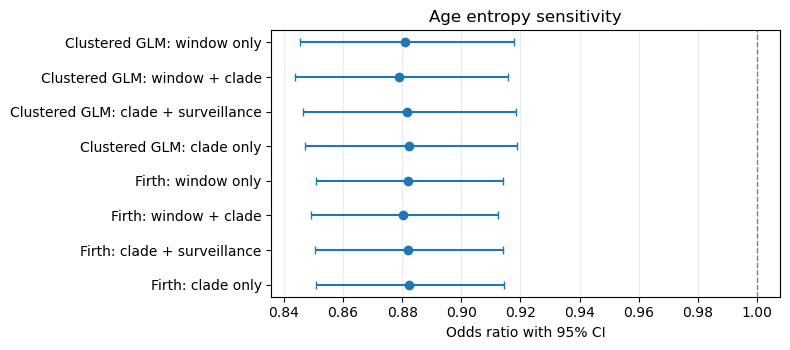

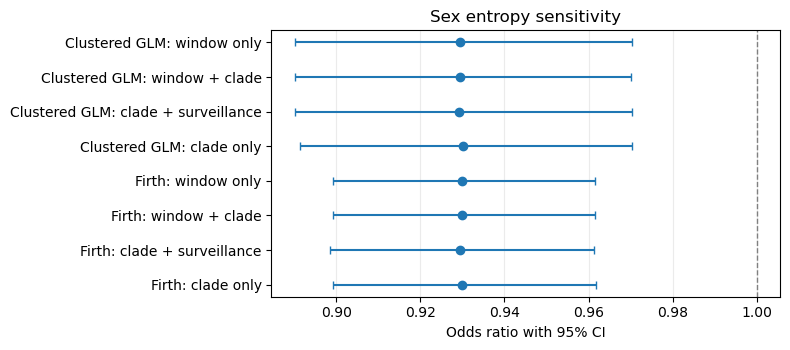

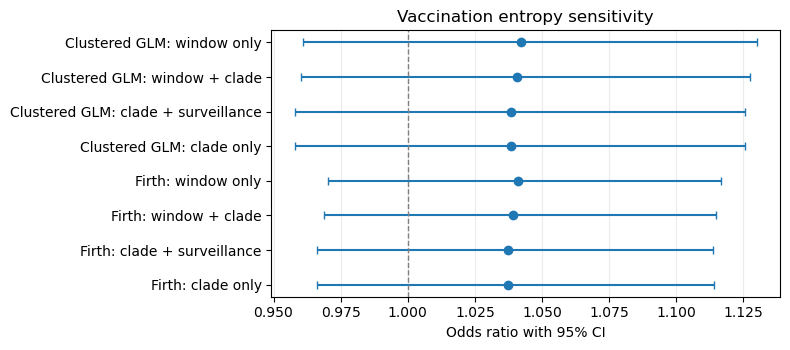

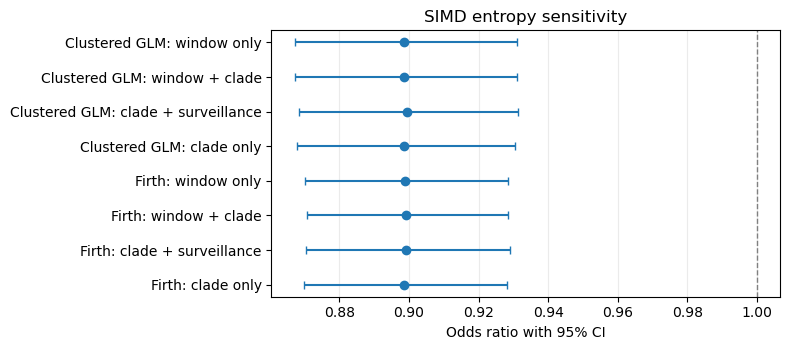

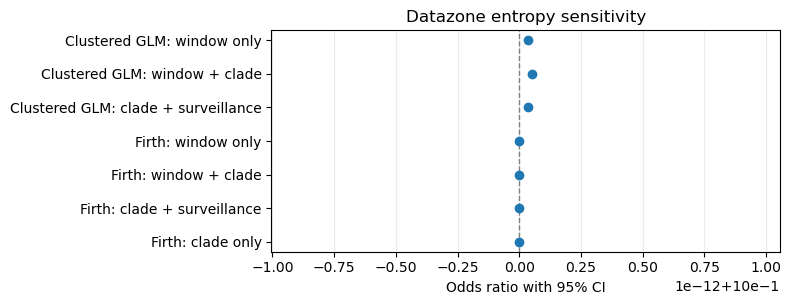

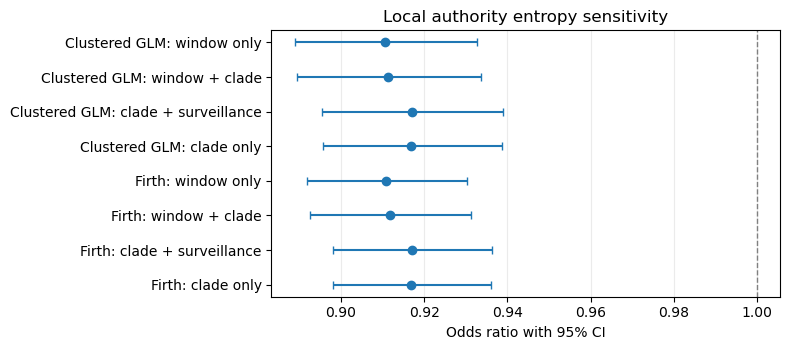

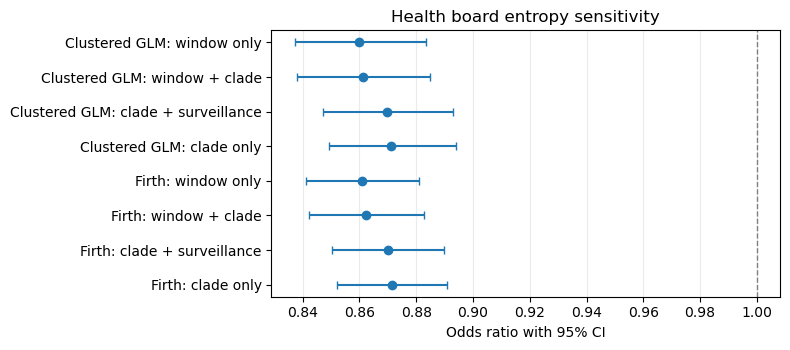

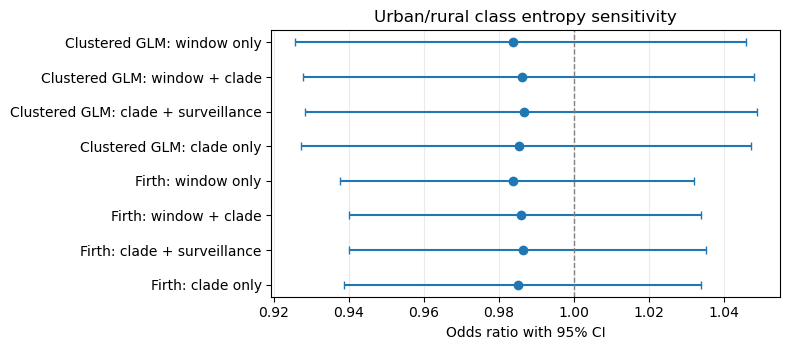

In [16]:
def plot_or_by_scenario(
    odds_table: pd.DataFrame,
    *,
    predictor: str,
    predictor_set: str = "single",
    domain: str = "node_mixing",
    title: str | None = None,
):
    panel = odds_table.loc[
        odds_table["domain"].eq(domain)
        & odds_table["predictor_set"].eq(predictor_set)
        & odds_table["predictor"].eq(predictor)
    ].copy()
    if panel.empty:
        raise ValueError(f"No rows found for predictor={predictor!r}.")

    panel["odds_ratio"] = pd.to_numeric(panel["odds_ratio"], errors="coerce")
    panel["or_low"] = pd.to_numeric(panel["or_low"], errors="coerce")
    panel["or_high"] = pd.to_numeric(panel["or_high"], errors="coerce")
    panel = panel.dropna(subset=["odds_ratio", "or_low", "or_high"])
    panel = panel.sort_values(["model_method", "scenario"])

    fig, ax = plt.subplots(figsize=(8, max(3, 0.45 * len(panel))))
    y = np.arange(len(panel))
    xerr = np.vstack(
        [
            panel["odds_ratio"] - panel["or_low"],
            panel["or_high"] - panel["odds_ratio"],
        ]
    )
    ax.errorbar(panel["odds_ratio"], y, xerr=xerr, fmt="o", capsize=3)
    ax.axvline(1.0, color="0.5", linestyle="--", linewidth=1)
    ax.set_yticks(y)
    ax.set_yticklabels(panel["scenario_label"])
    ax.set_xlabel("Odds ratio with 95% CI")
    ax.set_title(title or predictor)
    ax.grid(axis="x", alpha=0.25)
    fig.tight_layout()
    return fig, ax


_, _ = plot_or_by_scenario(
    odds_primary, predictor="age_entropy_z", title="Age entropy sensitivity"
)
_, _ = plot_or_by_scenario(
    odds_primary, predictor="sex_entropy_z", title="Sex entropy sensitivity"
)
_, _ = plot_or_by_scenario(
    odds_primary,
    predictor="vaccination_entropy_z",
    title="Vaccination entropy sensitivity",
)
_, _ = plot_or_by_scenario(
    odds_primary, predictor="simd_entropy_z", title="SIMD entropy sensitivity"
)
_, _ = plot_or_by_scenario(
    odds_primary, predictor="datazone_entropy_z", title="Datazone entropy sensitivity"
)
_, _ = plot_or_by_scenario(
    odds_primary,
    predictor="local_authority_entropy_z",
    title="Local authority entropy sensitivity",
)
_, _ = plot_or_by_scenario(
    odds_primary,
    predictor="health_board_entropy_z",
    title="Health board entropy sensitivity",
)
_, _ = plot_or_by_scenario(
    odds_primary,
    predictor="urban_rural_entropy_z",
    title="Urban/rural class entropy sensitivity",
)

## Largest Changes From The Reference Model

In [17]:
largest_changes = or_change.loc[
    ~or_change["scenario"].eq(REFERENCE_SCENARIO)
].sort_values("abs_delta_log_or_vs_ref", ascending=False)[
    [
        "scenario",
        "scenario_label",
        "model_method",
        "adjustment",
        "domain",
        "predictor_set",
        "predictor",
        "term",
        "odds_ratio",
        "odds_ratio_ref",
        "or_ratio_vs_ref",
        "delta_log_or_vs_ref",
        "p_value",
        "p_value_ref",
        "direction_changed",
    ]
]
largest_changes.to_csv(COMBINED_DIR / "largest_primary_or_changes.csv", index=False)
largest_changes.head(40)

,scenario,scenario_label,model_method,adjustment,domain,predictor_set,predictor,term,odds_ratio,odds_ratio_ref,or_ratio_vs_ref,delta_log_or_vs_ref,p_value,p_value_ref,direction_changed
569,glm_clade_surveillance,Clustered GLM: clade + surveillance,glm_clustered,window=surveillance; variant=clade,composition,single,health_board,"C(dz_health_board, Treatment(reference='Greater Glasgow and Clyde'))[T.Western Isles]",1.474239,2.311077,0.637901,-0.449572,3.986264e-01,1.013969e-12,False
265,firth_clade_surveillance,Firth: clade + surveillance,firth_glm,window=surveillance; variant=clade,composition,single,health_board,"C(dz_health_board, Treatment(reference='Greater Glasgow and Clyde'))[T.Western Isles]",1.475593,2.311077,0.638487,-0.448654,8.071538e-04,1.013969e-12,False
607,glm_clade_surveillance,Clustered GLM: clade + surveillance,glm_clustered,window=surveillance; variant=clade,composition,joint,all_composition,"C(dz_health_board, Treatment(reference='Greater Glasgow and Clyde'))[T.Western Isles]",1.616697,2.393637,0.675414,-0.392429,3.000315e-01,4.068438e-13,False
303,firth_clade_surveillance,Firth: clade + surveillance,firth_glm,window=surveillance; variant=clade,composition,joint,all_composition,"C(dz_health_board, Treatment(reference='Greater Glasgow and Clyde'))[T.Western Isles]",1.617875,2.393637,0.675907,-0.391700,5.281173e-05,4.068438e-13,False
493,glm_clade_only,Clustered GLM: clade only,glm_clustered,window=none; variant=clade,composition,single,health_board,"C(dz_health_board, Treatment(reference='Greater Glasgow and Clyde'))[T.Western Isles]",1.569132,2.311077,0.678961,-0.387191,3.355342e-01,1.013969e-12,False
189,firth_clade_only,Firth: clade only,firth_glm,window=none; variant=clade,composition,single,health_board,"C(dz_health_board, Treatment(reference='Greater Glasgow and Clyde'))[T.Western Isles]",1.570631,2.311077,0.679610,-0.386236,9.041180e-05,1.013969e-12,False
531,glm_clade_only,Clustered GLM: clade only,glm_clustered,window=none; variant=clade,composition,joint,all_composition,"C(dz_health_board, Treatment(reference='Greater Glasgow and Clyde'))[T.Western Isles]",1.741966,2.393637,0.727749,-0.317799,2.344124e-01,4.068438e-13,False
227,firth_clade_only,Firth: clade only,firth_glm,window=none; variant=clade,composition,joint,all_composition,"C(dz_health_board, Treatment(reference='Greater Glasgow and Clyde'))[T.Western Isles]",1.743287,2.393637,0.728301,-0.317041,2.572172e-06,4.068438e-13,False
490,glm_clade_only,Clustered GLM: clade only,glm_clustered,window=none; variant=clade,composition,single,health_board,"C(dz_health_board, Treatment(reference='Greater Glasgow and Clyde'))[T.Orkney]",1.070311,1.384331,0.773161,-0.257267,8.879425e-01,4.171546e-05,False
186,firth_clade_only,Firth: clade only,firth_glm,window=none; variant=clade,composition,single,health_board,"C(dz_health_board, Treatment(reference='Greater Glasgow and Clyde'))[T.Orkney]",1.071542,1.384331,0.774050,-0.256119,3.696738e-01,4.171546e-05,False


## Interpretation Checklist

Use this notebook to separate three cases:

1. Stable association: direction and approximate magnitude are similar across Firth and clustered GLM, and across adjustment sets.
2. Adjustment-sensitive association: direction or magnitude changes materially when either `C(window_idx)` or `C(clade)` is removed. Treat this as confounding-sensitive.
3. Numerically unstable association: key Firth fits are non-converged or warn, especially if the corresponding GLM or simplified adjustment changes materially. Treat these as sensitivity-only unless further diagnostics support them.

The combined comparison CSVs are written to `sse_detection/results/main_model_sensitivity/combined/`.